# 1. 함수 $f(x)=2*sin(x)+0.5*x$의 최소값 탐색

## 1-1. 미분법

기울기가 0인 지점들: [-4.459708725242611, -1.8234765819369754, 1.8234765819369754, 4.459708725242611, 8.106661889116562, 10.742894032422196]
최소값 :  -2.848229964072196


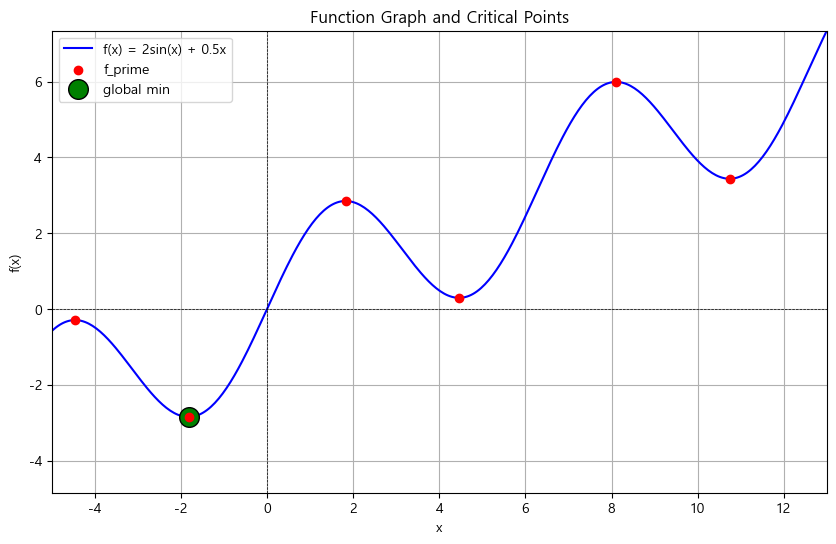

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2 * np.sin(x) + 0.5 * x

x_values = np.linspace(-5, 13, 400)  # -5부터 13까지 400개의 점 생성
y_values = f(x_values)  # y 값 계산

def critical_points_in_range(): # 기울기가 0이 되는 지점 탐색
    cos_value = -0.25
    angles = np.arccos(cos_value)  # arccos를 통해 주어진 값의 각도를 구함
    solutions = [angles, -angles]

    n_values = np.arange(-3, 4)  # -3π 부터 3π까지
    for n in n_values:
        for solution in solutions:
            x_value = solution + n * 2 * np.pi
            if -5 <= x_value <= 13:
                yield x_value

# 기울기가 0인 x 값들
critical_points = list(critical_points_in_range())
critical_points.sort()

# y 값 계산 (x 값과 그에 대응하는 y 값을 튜플로 저장)
y_values = [(x, f(x)) for x in critical_points]

# 가장 작은 y값의 위치 찾기
min_y_point = min(y_values, key=lambda item: item[1])

print("기울기가 0인 지점들:", critical_points)
print("최소값 : ", min_y_point[1])

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(x_values, f(x_values), label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(critical_points, f(np.array(critical_points)), color='red', label='f_prime', zorder=10)
plt.scatter(min_y_point[0], min_y_point[1], color='green', s=200, label='global min', zorder=6, edgecolor='black')
plt.title('Function Graph and Critical Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid()
plt.legend()
plt.xlim(-5, 13)
plt.ylim(min(f(x_values))-2, max(f(x_values)))
plt.show()

## 1-2. 뉴턴법

In [13]:
import numpy as np

# 도함수 정의
def f_prime(x): 
    return 2 * np.cos(x) + 0.5 

# 초기값 설정
x0 = 13
tolerance = 1e-6  # 수렴 허용 오차
max_iterations = 100  # 최대 반복 횟수
iteration = 0

# 뉴턴법 적용
while iteration < max_iterations:
    slope = f_prime(x0)  # 현재 기울기 계산
    
    # 기울기가 0에 도달할 때까지 이동
    if slope > 0:  # 기울기가 양수면 왼쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 왼쪽으로 이동
    else:  # 기울기가 음수면 오른쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 오른쪽으로 이동

    # x의 범위 제한
    if x1 < -5 or x1 > 13:
        break

    # 기울기가 0인지 검사
    if abs(f_prime(x1)) < tolerance:
        break

    x0 = x1  # 업데이트
    iteration += 1

x1, f(x1)  # 기울기가 0인 지점과 해당 함수 값 반환

(10.742894484624905, 3.434955343107588)

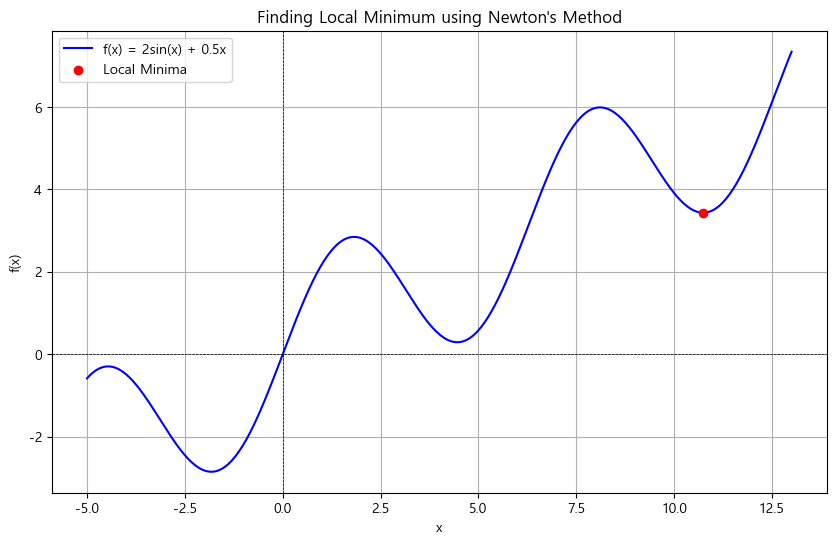

In [14]:
x_values = np.linspace(-5, 13, 400)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(x1, f(x1), color='red', label='Local Minima', zorder=5)
plt.title('Finding Local Minimum using Newton\'s Method')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid()
plt.legend()
plt.show()

## 1-3. 경사하강법

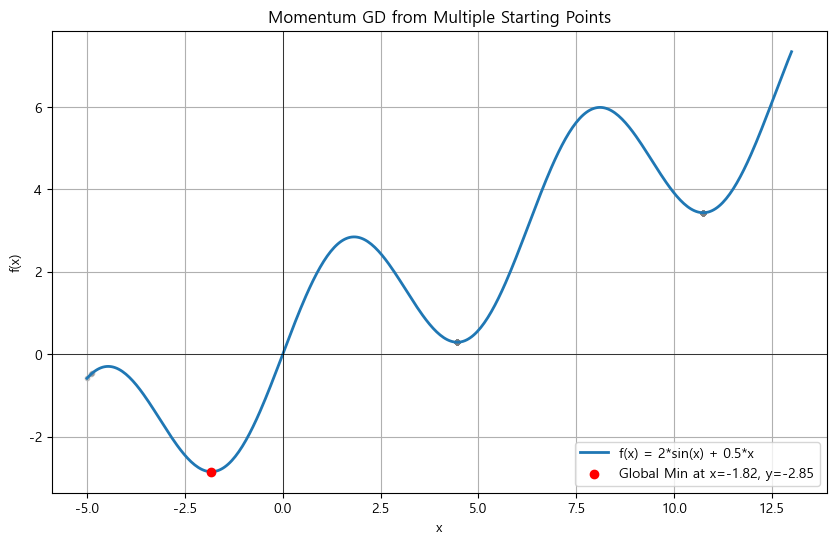

momentum_score: -1.3636363636363633, 
x: -1.8234684114155872, 
y: -2.8482299640075586


In [15]:
# sympy 함수 사용을 위한 재정의
import sympy as sp

# 심볼릭 변수 및 함수 정의
x_sym = sp.symbols('x')
f_sym = 2 * sp.sin(x_sym) + 0.5 * x_sym

# 도함수 계산
f_prime = sp.diff(f_sym, x_sym)

# 수치 계산을 위한 함수 변환
f_lambdified = sp.lambdify(x_sym, f_sym, modules=["numpy"])
f_prime_lambdified = sp.lambdify(x_sym, f_prime, modules=["numpy"])

# 모멘텀을 사용하는 경사하강법 함수 정의
def gradient_descent_with_momentum(f_prime, x0, learning_rate=0.01, momentum=0.9, tol=1e-6, max_iter=1000, x_min=-5, x_max=13):
    x = x0
    v = 0
    for _ in range(max_iter):
        grad = f_prime(x)
        v = momentum * v - learning_rate * grad
        x_new = x + v
        if x_new < x_min or x_new > x_max:
            break
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

# 초기값을 linspace로 설정
initial_values = np.linspace(-5, 13, 100)
results = []

# 각 초기값마다 경사하강법 실행
for x0 in initial_values:
    x_opt = gradient_descent_with_momentum(
        f_prime_lambdified, x0, learning_rate=0.1, momentum=0.9, max_iter=1000
    )
    y_opt = f_lambdified(x_opt)
    results.append((x0, x_opt, y_opt))

# 최소값 탐색
best_result = min(results, key=lambda x: x[2])  # y_opt 기준 최소값

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2*sin(x) + 0.5*x', linewidth=2)

# 여러 초기값에서 수렴한 최적점 표시
for _, x_opt, y_opt in results:
    plt.scatter(x_opt, y_opt, color='gray', alpha=0.4, s=10)

# 최적 최소값 표시
plt.scatter(best_result[1], best_result[2], color='red', label=f"Global Min at x={best_result[1]:.2f}, y={best_result[2]:.2f}", zorder=5)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Momentum GD from Multiple Starting Points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

best_result
print(f'momentum_score: {best_result[0]}, \nx: {best_result[1]}, \ny: {best_result[2]}')

## 1-4. 유전알고리즘을 이용해 최솟값 탐색

In [3]:
import random
import numpy as np
from itertools import product
from toolbox import (
    selection_proportional, selection_rank, selection_rank_with_elite,
    selection_stochastic_universal_sampling, selection_tournament,
    crossover_blend, crossover_linear, crossover_uniform,
    crossover_n_point, crossover_one_point,
    mutation_random_deviation, mutation_bit_flip,
    mutation_fitness_driven_random_deviation, mutation_fitness_driven_bit_flip
)

def func(x):
    return 2 * np.sin(x) + 0.5 * x

class RealIndividual:
    def __init__(self, gene_list) -> None:
        if isinstance(gene_list, RealIndividual):
            self.gene_list = gene_list.gene_list
        else:
            self.gene_list = gene_list if isinstance(gene_list, list) else [gene_list]
        self.gene_list[0] = max(min(self.gene_list[0], 13), -5)
        self.fitness = -func(self.gene_list[0])

    def __str__(self):
        return f'x: {self.gene_list[0]}, f(x): {func(self.gene_list[0])}'

class BinaryIndividual:
    def __init__(self, gene_list=None, bits=16):
        self.bits = bits
        self.min_value = -5
        self.max_value = 13

        if gene_list is None:
            self.gene_list = [random.randint(0, 1) for _ in range(bits)]
        else:
            self.gene_list = gene_list

        self.x = self._decode_binary()
        self.fitness = -func(self.x)

    def _decode_binary(self):
        sign = -1 if self.gene_list[0] == 1 else 1
        value = 0
        for i, bit in enumerate(self.gene_list[1:], 1):
            value = value * 2 + bit
        max_binary = 2 ** (self.bits - 1) - 1
        scaled = sign * (value / max_binary) * self.max_value
        return max(min(scaled, self.max_value), self.min_value)

    def __str__(self):
        binary = ''.join(map(str, self.gene_list))
        return f'Binary: {binary}, x: {self.x:.4f}, f(x): {func(self.x):.4f}'

class AdaptiveGA:
    def __init__(self, encoding_type='real', population_size=50, max_generations=200,
                 initial_crossover_prob=0.9, final_crossover_prob=0.7,
                 initial_mutation_prob=0.3, final_mutation_prob=0.1,
                 elite_size=3, bits=20):
        self.encoding_type = encoding_type
        self.population_size = population_size
        self.max_generations = max_generations
        self.initial_crossover_prob = initial_crossover_prob
        self.final_crossover_prob = final_crossover_prob
        self.initial_mutation_prob = initial_mutation_prob
        self.final_mutation_prob = final_mutation_prob
        self.elite_size = elite_size
        self.bits = bits
        self.convergence_threshold = 1e-12
        self.convergence_generations = 10

    def get_adaptive_rates(self, generation):
        """세대에 따라 교차/돌연변이 확률 조정"""
        progress = generation / self.max_generations
        crossover_prob = self.initial_crossover_prob - (self.initial_crossover_prob - self.final_crossover_prob) * progress
        mutation_prob = self.initial_mutation_prob - (self.initial_mutation_prob - self.final_mutation_prob) * progress
        return crossover_prob, mutation_prob

    def create_individual(self):
        """실수/이진 인코딩에 따른 개체 생성"""
        if self.encoding_type == 'real':
            return RealIndividual([random.uniform(-15, 15)])
        else:
            return BinaryIndividual(bits=self.bits)

    def hybrid_selection(self, population, generation):
        """하이브리드 선택 전략"""
        if generation % 2 == 0:
            return selection_rank_with_elite(population, elite_size=self.elite_size)
        else:
            return selection_tournament(population, group_size=3)

    def run(self, selection_method, crossover_tuple, mutation_tuple):
        """개선된 유전 알고리즘 실행"""
        population = [self.create_individual() for _ in range(self.population_size)]
        best_ever = min(population, key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
        
        prev_best_fx = float('inf')
        convergence_count = 0
        
        crossover_method, crossover_params = crossover_tuple
        mutation_method, mutation_params = mutation_tuple
        
        for generation in range(self.max_generations):
            # 적응적 확률 조정
            crossover_prob, mutation_prob = self.get_adaptive_rates(generation)
            
            # 하이브리드 선택 또는 일반 선택
            if selection_method == 'hybrid':
                selected = self.hybrid_selection(population, generation)
            else:
                selected = selection_method(population)

            # 교차
            offspring = []
            for p1, p2 in zip(selected[::2], selected[1::2]):
                if random.random() < crossover_prob:
                    if self.encoding_type == 'real':
                        # 각 교차 연산자에 맞는 파라미터 적용
                        current_params = crossover_params.copy()
                        if 'alpha' in current_params and generation >= self.max_generations // 2:
                            current_params['alpha'] *= 0.6
                        elif 'prop' in current_params and generation >= self.max_generations // 2:
                            current_params['prop'] = min(0.7, current_params['prop'] * 1.2)
                        c1, c2 = crossover_method(p1.gene_list, p2.gene_list, **current_params)
                    else:
                        c1, c2 = crossover_method(p1.gene_list, p2.gene_list, **crossover_params)
                    offspring.extend([
                        RealIndividual(c1) if self.encoding_type == 'real' else BinaryIndividual(c1, self.bits),
                        RealIndividual(c2) if self.encoding_type == 'real' else BinaryIndividual(c2, self.bits)
                    ])
                else:
                    offspring.extend([p1, p2])

            # 돌연변이
            mutated_offspring = []
            for ind in offspring:
                if random.random() < mutation_prob:
                    if self.encoding_type == 'real':
                        # 세대에 따라 sigma 값 조정
                        current_sigma = mutation_params['sigma'] if generation < self.max_generations // 2 else mutation_params['sigma'] * 0.5
                        current_params = {**mutation_params, 'sigma': current_sigma}
                        mutated = mutation_method(ind.gene_list, **current_params)
                    else:
                        mutated = mutation_method(ind.gene_list, **mutation_params)
                    mutated_offspring.append(
                        RealIndividual(mutated) if self.encoding_type == 'real' else BinaryIndividual(mutated, self.bits)
                    )
                else:
                    mutated_offspring.append(ind)

            # 엘리트 보존
            population = sorted(mutated_offspring, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
            if self.elite_size > 0:
                elite = sorted(population, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))[:self.elite_size]
                population = elite + population[:-self.elite_size]

            # 현재 세대의 최소값 갱신
            current_best = min(population, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
            current_fx = func(current_best.gene_list[0] if self.encoding_type == 'real' else current_best.x)

            if current_fx < func(best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x):
                best_ever = current_best

            # 수렴 검사
            if abs(current_fx - prev_best_fx) < self.convergence_threshold:
                convergence_count += 1
            else:
                convergence_count = 0
            
            if convergence_count >= self.convergence_generations:
                break
                
            prev_best_fx = current_fx

        return {
            'generations': generation + 1,
            'best_fx': func(best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x),
            'best_x': best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x,
            'binary': ''.join(map(str, best_ever.gene_list)) if self.encoding_type == 'binary' else None
        }


# 실험 설정 및 실행
experiment_settings = [
    {
        'encoding_type': 'real',
        'population_size': 100,
        'max_generations': 200,
        'initial_crossover_prob': 0.9,
        'final_crossover_prob': 0.7,
        'initial_mutation_prob': 0.3,
        'final_mutation_prob': 0.1,
        'elite_size': 3,
    },
    {
        'encoding_type': 'binary',
        'population_size': 100,
        'max_generations': 200,
        'initial_crossover_prob': 0.9,
        'final_crossover_prob': 0.7,
        'initial_mutation_prob': 0.3,
        'final_mutation_prob': 0.1,
        'elite_size': 3,
        'bits': 24,
    }
]

best_overall = None

for setting in experiment_settings:
    print(f"\n{setting['encoding_type'].upper()} 인코딩 실험 시작...")

    ga = AdaptiveGA(**setting)
    results = []

    if setting['encoding_type'] == 'real':
        real_crossover_methods = [
            (crossover_blend, {'alpha': 0.5}),
            (crossover_linear, {'alpha': 0.7}),
            (crossover_uniform, {'prop': 0.5})
        ]
        real_mutation_methods = [
            (mutation_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 0.1}),
            (mutation_fitness_driven_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 0.1, 'max_tries': 3})
        ]
        combinations = [
            (selection_rank_with_elite, real_crossover_methods[0], real_mutation_methods[0]),
            (selection_tournament, real_crossover_methods[1], real_mutation_methods[0]),
            ('hybrid', real_crossover_methods[2], real_mutation_methods[1]),
        ]
    else:
        binary_crossover_methods = [
            (crossover_one_point, {}),
            (crossover_n_point, {'n': 2}),
            (crossover_uniform, {'prop': 0.5})
        ]
        binary_mutation_methods = [
            (mutation_bit_flip, {}),
            (mutation_fitness_driven_bit_flip, {'max_tries': 3})
        ]
        combinations = [
            (selection_rank_with_elite, binary_crossover_methods[0], binary_mutation_methods[0]),
            (selection_tournament, binary_crossover_methods[1], binary_mutation_methods[0]),
            ('hybrid', binary_crossover_methods[2], binary_mutation_methods[1]),
        ]

    for selection, crossover, mutation in combinations:
        result = ga.run(selection, crossover, mutation)
        result_summary = {
            'encoding': setting['encoding_type'],
            'selection': selection if isinstance(selection, str) else selection.__name__,
            'crossover': crossover[0].__name__,
            'mutation': mutation[0].__name__,
            **result
        }
        results.append(result_summary)

        print(f"- 조합: {result_summary['selection']} / {result_summary['crossover']} / {result_summary['mutation']}")
        print(f"  -> 세대 수: {result_summary['generations']}, f(x): {result_summary['best_fx']:.6f}, x: {result_summary['best_x']:.6f}")

        if best_overall is None or result_summary['best_fx'] < best_overall['best_fx']:
            best_overall = result_summary

# 최종 최적 결과 출력
print("\n===== 최종 최적 결과 =====")
print(f"- 인코딩 방식: {best_overall['encoding']}")
print(f"- 선택 연산자: {best_overall['selection']}")
print(f"- 교차 연산자: {best_overall['crossover']}")
print(f"- 돌연변이 연산자: {best_overall['mutation']}")
print(f"- 세대 수: {best_overall['generations']}")
print(f"- 최적 x: {best_overall['best_x']:.6f}")
print(f"- 최소 f(x): {best_overall['best_fx']:.6f}")
if best_overall['encoding'] == 'binary':
    print(f"- 이진 표현: {best_overall['binary']}")



REAL 인코딩 실험 시작...
- 조합: selection_rank_with_elite / crossover_blend / mutation_random_deviation
  -> 세대 수: 17, f(x): -2.848218, x: -1.820000
- 조합: selection_tournament / crossover_linear / mutation_random_deviation
  -> 세대 수: 15, f(x): -2.848218, x: -1.820000


AttributeError: 'list' object has no attribute 'fitness'

# 2번 최적화 문제를 유전알고리즘을 통해 해 탐색

**목적 함수:**

max  $x_1 + 2x_2$

**제약 조건 (S.t.):**

* $-x_1 + x_2 \le 5$
* $x_1 + x_2 \le 10$
* $-2x_1 + x_2 \ge -10$
* $x_1, x_2 \ge 0$

**유전 알고리즘 조건:**

* 해의 표현: 이진수 5자리
* 적합도 함수: 목적식 (제약식을 만족 못하면 0점)
* 최대 세대수: 30
* 종료 조건: 최대 세대 수 도달
* 교차 연산: 1점 교차 연산
* 부모 수: 10
* 돌연변이 연산자: flip bit 돌연변이 연산
* 돌연변이 비율: 10%
* 돌연변이 유전 개체 비율: 20%

## 문제 설명 추가
여러 시드 설정해서 일반화

In [11]:
import random
import copy

# 문제 조건
MAX_GENERATIONS = 30
POPULATION_SIZE = 10  # 부모 수 (여기서는 편의상 전체 개체 수를 부모 수로 사용)
CHROMOSOME_LENGTH = 5  # 이진수 5자리
MUTATION_RATE = 0.1
MUTATION_INDIVIDUAL_RATE = 0.2

# 제약 조건 함수
def is_feasible(x1, x2):
    if x1 < 0 or x2 < 0:
        return False
    if -x1 + x2 > 5:
        return False
    if x1 + x2 > 10:
        return False
    if -2*x1 + x2 < -10:
        return False
    return True

# 적합도 함수
def fitness_function(x1, x2):
    if is_feasible(x1, x2):
        return x1 + 2*x2
    else:
        return 0

# 이진수 -> 십진수 변환 함수
def binary_to_decimal(binary):
    return int(binary, 2)

# 개체 생성 함수
def create_individual(length):
    return [random.randint(0, 1) for _ in range(length)]

# 초기 모집단 생성 함수
def create_population(size, length):
    return [create_individual(length) for _ in range(size)]

# 선택 함수 (토너먼트 선택)
def selection(population, fitnesses, num_parents):
    parents = []
    for _ in range(num_parents):
        tournament_indices = random.sample(range(len(population)), 3)  # 토너먼트 크기 = 3
        tournament_fitnesses = [fitnesses[i] for i in tournament_indices]
        winner_index = tournament_indices[tournament_fitnesses.index(max(tournament_fitnesses))]
        parents.append(population[winner_index])
    return parents

def crossover(p1, p2):
    point = random.randint(1, len(p1) - 1)
    c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)
    c1[point:], c2[point:] = p2[point:], p1[point:]
    return c1, c2

# 돌연변이 연산 (bit-flip)
def mutation_bit_flip(ind):
    mut = copy.deepcopy(ind)
    pos = random.randint(0, len(ind)-1)
    mut[pos] = (mut[pos] + 1) % 2
    return mut

# 유전 알고리즘 메인 함수
def genetic_algorithm(random_seed):
    random.seed(random_seed)  # 시드 값 설정
    population = create_population(POPULATION_SIZE, CHROMOSOME_LENGTH * 2)  # x1, x2 모두 표현하므로 *2
    best_fitness = 0
    best_individual = None
    final_fitnesses = []  # 최종 세대 적합도 분포 저장
    final_x1 = 0
    final_x2 = 0

    for generation in range(MAX_GENERATIONS):
        # 이진수 -> 십진수 변환
        x1_binaries = [ "".join(map(str,ind[:CHROMOSOME_LENGTH])) for ind in population]
        x2_binaries = [ "".join(map(str,ind[CHROMOSOME_LENGTH:])) for ind in population]

        x1_decimals = [binary_to_decimal(binary) for binary in x1_binaries]
        x2_decimals = [binary_to_decimal(binary) for binary in x2_binaries]

        # 적합도 계산
        fitnesses = [fitness_function(x1, x2) for x1, x2 in zip(x1_decimals, x2_decimals)]
        final_fitnesses = fitnesses  # 최종 세대 적합도 분포 저장

        # 현재 세대 최고 적합도 갱신
        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[fitnesses.index(max(fitnesses))]
            final_x1 = x1_decimals[fitnesses.index(max(fitnesses))]
            final_x2 = x2_decimals[fitnesses.index(max(fitnesses))]

        # 선택
        parents = selection(population, fitnesses, POPULATION_SIZE)

        # 교차
        offsprings = []
        for i in range(0, POPULATION_SIZE, 2):
            c1, c2 = crossover(parents[i % len(parents)], parents[(i + 1) % len(parents)])
            offsprings.append(c1)
            offsprings.append(c2)

        # 돌연변이
        num_mutation_individuals = int(POPULATION_SIZE * MUTATION_INDIVIDUAL_RATE)
        mutation_targets = random.sample(range(len(offsprings)), num_mutation_individuals)

        for i in mutation_targets:
            if random.random() < MUTATION_RATE:
                offsprings[i] = mutation_bit_flip(offsprings[i])

        population = offsprings

    # 최종 결과 해석
    if best_individual is not None:
        x1_final = binary_to_decimal("".join(map(str,best_individual[:CHROMOSOME_LENGTH])))
        x2_final = binary_to_decimal("".join(map(str,best_individual[CHROMOSOME_LENGTH:])))
        return x1_final, x2_final, final_fitnesses  # 최종 적합도 분포 반환
    else:
        return final_x1, final_x2, final_fitnesses  # 최종 적합도 분포 반환

# 실행 (여러 초기값에 대해 테스트)
random_seed_list = [0, 1, 2, 3, 4, 5]  # 테스트할 시드 값 리스트

for seed in random_seed_list:
    x1, x2, fitnesses = genetic_algorithm(seed)  # 결과 받음
    print(f"\n[Seed: {seed}]")
    if isinstance(x1, int): # x1이 int 타입이면 최적해를 찾은 것으로 간주
        max_fitness = fitness_function(x1, x2)
        print(f"  최적해: x1 = {x1}, x2 = {x2}, 최대값 = {max_fitness}")
        print(f"  최종 모집단 적합도 분포: {fitnesses}")
    else:
        if fitnesses:
            print(f"  최적해를 찾지 못했습니다.")
            print(f"  최종 세대 최고 적합도 개체 x1: {x1}, x2: {x2}")
            print(f"  최종 모집단 적합도 분포: {fitnesses}")
        else:
            print(f"  최적해를 찾지 못했습니다.")
            print(f"  최종 세대 적합도 정보 없음")


[Seed: 0]
  최적해: x1 = 3, x2 = 7, 최대값 = 17
  최종 모집단 적합도 분포: [17, 17, 17, 17, 17, 17, 17, 17, 17, 17]

[Seed: 1]
  최적해: x1 = 0, x2 = 0, 최대값 = 0
  최종 모집단 적합도 분포: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[Seed: 2]
  최적해: x1 = 2, x2 = 7, 최대값 = 16
  최종 모집단 적합도 분포: [16, 16, 16, 16, 16, 16, 16, 16, 16, 16]

[Seed: 3]
  최적해: x1 = 5, x2 = 1, 최대값 = 7
  최종 모집단 적합도 분포: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

[Seed: 4]
  최적해: x1 = 3, x2 = 3, 최대값 = 9
  최종 모집단 적합도 분포: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]

[Seed: 5]
  최적해: x1 = 3, x2 = 7, 최대값 = 17
  최종 모집단 적합도 분포: [17, 0, 17, 17, 17, 17, 17, 17, 17, 17]


# 3. 최단경로 문제 유전알고리즘으로 최적 경로 탐색
## + 문제 설명

주어진 경로: 
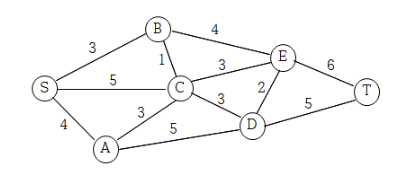

Starting Genetic Algorithm...
Generation 1/100, Best Distance: 31.00, Avg Valid Distance: 31.00
Generation 11/100, Best Distance: 27.00, Avg Valid Distance: 29.00
Generation 21/100, Best Distance: 27.00, Avg Valid Distance: 28.37
Generation 31/100, Best Distance: 27.00, Avg Valid Distance: 27.34
Generation 41/100, Best Distance: 27.00, Avg Valid Distance: 27.17
Generation 51/100, Best Distance: 27.00, Avg Valid Distance: 27.25
Generation 61/100, Best Distance: 27.00, Avg Valid Distance: 27.15
Generation 71/100, Best Distance: 27.00, Avg Valid Distance: 27.85
Generation 81/100, Best Distance: 27.00, Avg Valid Distance: 27.00
Generation 91/100, Best Distance: 27.00, Avg Valid Distance: 27.10

--- Optimization Complete ---
Best Path Found: ['S', 'B', 'C', 'E', 'T', 'D', 'A', 'S']
Best Distance: 27


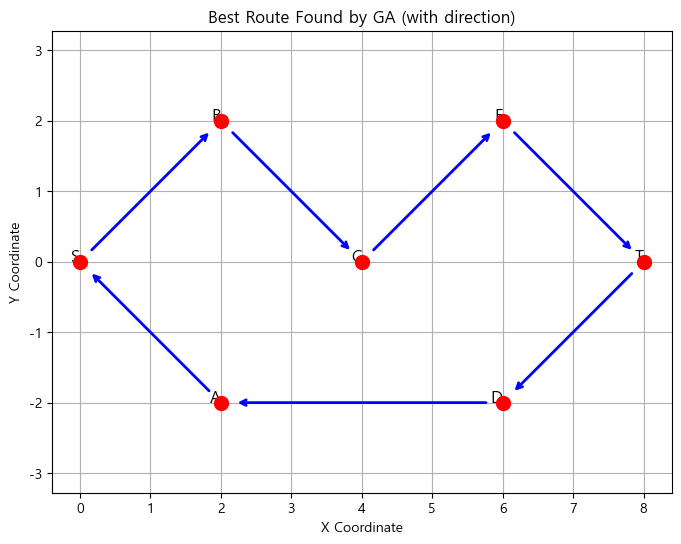

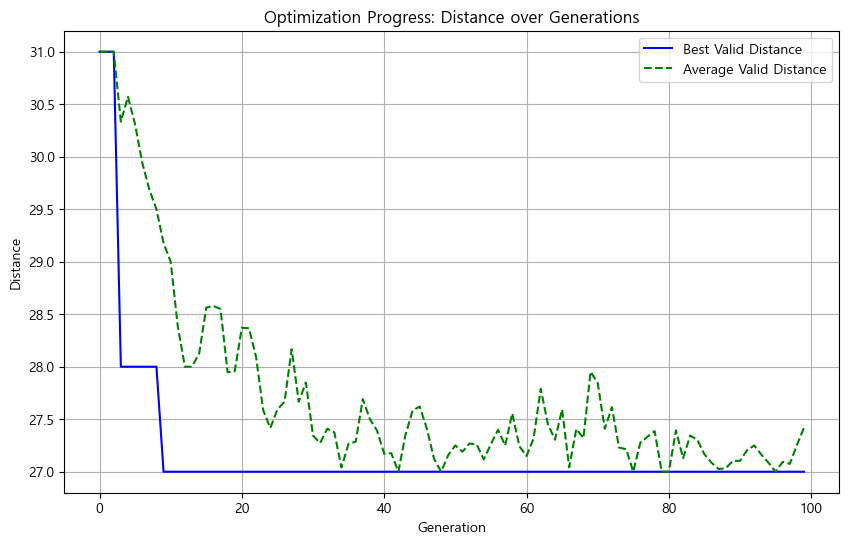

In [9]:
import random
import copy
import matplotlib.pyplot as plt

random.seed(0)

# 1. 노드 및 간선 정보 정의
nodes = {'S', 'A', 'B', 'C', 'D', 'E', 'T'}
edges = {
    ('S', 'A'): 4, ('A', 'S'): 4,
    ('S', 'B'): 3, ('B', 'S'): 3,
    ('S', 'C'): 5, ('C', 'S'): 5,
    ('A', 'C'): 3, ('C', 'A'): 3,
    ('A', 'D'): 5, ('D', 'A'): 5,
    ('B', 'C'): 1, ('C', 'B'): 1,
    ('B', 'E'): 4, ('E', 'B'): 4,
    ('C', 'D'): 3, ('D', 'C'): 3,
    ('C', 'E'): 3, ('E', 'C'): 3,
    ('D', 'E'): 2, ('E', 'D'): 2,
    ('D', 'T'): 5, ('T', 'D'): 5,
    ('E', 'T'): 6, ('T', 'E'): 6
}

# 노드 좌표를 딕셔너리로 정의 (시각화를 위해)
node_coords = {
    'S': (0, 0),
    'A': (2, -2),
    'B': (2, 2),
    'C': (4, 0),
    'D': (6, -2),
    'E': (6, 2),
    'T': (8, 0)
}

# 2. 유전 알고리즘 파라미터 설정
POPULATION_SIZE = 100
MAX_GENERATIONS = 100
CROSSOVER_PROBABILITY = 0.9
MUTATION_PROBABILITY = 0.1
ELITE_SIZE = 10
INVALID_PATH_PENALTY = 100


# 3. Individual 클래스 및 관련 함수 정의
class Individual:
    def __init__(self, path):
        self.path = path
        self.fitness = self.calculate_fitness()

    def calculate_fitness(self):
        total_distance = 0
        full_path = ['S'] + self.path + ['S']

        # 매우 큰 페널티 값. 어떤 유효한 경로의 총 거리보다 커야 함.
        # INVALID_PATH_PENALTY = 100

        for i in range(len(full_path) - 1):
            u, v = full_path[i], full_path[i+1]
            # 해당 간선 (u, v)가 edges 딕셔너리에 존재하는지 확인
            if (u, v) not in edges:
                # 존재하지 않으면 이 경로는 유효하지 않으므로 큰 페널티를 부여
                # 최소화 문제(거리) -> 최대화 문제(적합도) 변환이므로,
                # 거리가 매우 커지도록 (음수 적합도가 매우 작아지도록) 설정
                return -INVALID_PATH_PENALTY

            total_distance += edges[(u, v)]

        # 유효한 경로인 경우 정상적으로 적합도 계산
        return -total_distance # 최소화 문제이므로 음수 반환

def create_initial_population(node_set, population_size):
    population = []
    other_nodes = list(node_set - {'S'})  # 'S'를 제외한 나머지 노드
    for _ in range(population_size):
        path = random.sample(other_nodes, len(other_nodes)) # 'S'를 제외한 노드의 순열
        population.append(Individual(list(path)))
    return population

# 4. 유전 연산 함수 정의
def selection(population, elite_size):
    # 적합도(fitness, 음수 거리) 내림차순 정렬 -> 거리는 오름차순
    sorted_population = sorted(population, key=lambda ind: ind.fitness, reverse=True)
    # 엘리트 선택 + 나머지 랜덤 선택 (정렬된 리스트에서)
    return sorted_population[:elite_size] + random.choices(sorted_population, k=len(population) - elite_size)

def crossover(parent1, parent2):
    # Ordered Crossover (OX1) 변형
    p1_path = parent1.path
    p2_path = parent2.path
    length = len(p1_path)
    # 교차 지점 두 개 랜덤 선택
    start, end = sorted(random.sample(range(length), 2))

    # 자식 경로 생성 및 부모1의 중간 부분 복사
    child_path = [None] * length
    child_path[start:end+1] = p1_path[start:end+1]

    # 부모2의 노드들을 순서대로 순회하며 자식 경로의 빈 칸 채우기
    remaining_nodes_in_p2_order = [node for node in p2_path if node not in p1_path[start:end+1]]
    
    current_remaining_index = 0
    for i in range(length):
        if child_path[i] is None:
            child_path[i] = remaining_nodes_in_p2_order[current_remaining_index]
            current_remaining_index += 1
            
    return Individual(child_path) # 새로운 Individual 객체 반환

def mutate(individual):
    # Swap mutation (두 노드의 위치를 바꿈)
    mutated_path = individual.path[:] # 경로 복사
    if len(mutated_path) > 1: # 노드가 2개 이상일 때만 돌연변이 가능
        idx1, idx2 = random.sample(range(len(mutated_path)), 2)
        mutated_path[idx1], mutated_path[idx2] = mutated_path[idx2], mutated_path[idx1]
    return Individual(mutated_path) # 새로운 Individual 객체 반환


# 5. 경로 유효성 검사 및 거리 계산 함수 정의 (GA 로직에서는 사용되지 않음, 디버깅/확인용)
# calculate_total_distance 함수는 Individual 클래스의 calculate_fitness와 동일한 역할을 하므로 중복입니다.
# is_valid_path 함수는 모든 노드를 방문하고 모든 간선이 존재하는지 확인하지만, 
# 현재 GA는 permutation 기반이라 모든 노드 방문은 보장되나, 간선 존재 여부는 calculate_fitness에서 체크합니다.

# 6. 결과 시각화 함수 정의
def visualize_route(best_path):
    full_path = ['S'] + best_path + ['S']
    # 노드 좌표는 그대로 사용

    plt.figure(figsize=(8, 6))
    
    # 노드 위치에 점과 이름 표시
    for node, (nx, ny) in node_coords.items():
        plt.plot(nx, ny, 'o', markersize=10, color='red', zorder=5) # 노드 점 표시 (화살표보다 위에 오도록 zorder 설정)
        plt.text(nx, ny, node, fontsize=12, ha='right') # 노드 이름 표시

    # 최적 경로의 각 간선에 화살표 그리기
    for i in range(len(full_path) - 1):
        start_node = full_path[i]
        end_node = full_path[i+1]
        (x1, y1) = node_coords[start_node]
        (x2, y2) = node_coords[end_node]

        # annotate 함수를 사용하여 화살표 그리기
        plt.annotate(
            '', xy=(x2, y2), xycoords='data',
            xytext=(x1, y1), textcoords='data',
            arrowprops=dict(
                arrowstyle='->',    # 화살표 스타일 지정
                color='blue',       # 화살표 색상
                lw=2,               # 선 굵기
                shrinkA=12,         # 시작점에서 화살표를 약간 줄여 노드와 겹치지 않게 함
                shrinkB=12,         # 끝점에서 화살표를 약간 줄여 노드와 겹치지 않게 함
                connectionstyle='arc3,rad=0' # 직선 화살표
            )
        )

        # (선택 사항) 간선 위에 거리 표시 - 그래프가 복잡해질 수 있습니다.
        # mid_x = (x1 + x2) / 2
        # mid_y = (y1 + y2) / 2
        # distance = edges.get((start_node, end_node), '?') # 간선 거리를 가져옴
        # plt.text(mid_x, mid_y, str(distance), fontsize=8, color='gray', ha='center', va='bottom')


    plt.title('Best Route Found by GA (with direction)')
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.axis('equal') # x, y 축 스케일을 같게 하여 실제 그래프 모양에 가깝게 표시
    # plt.legend() # 각 경로 세그먼트가 독립적이므로 범례는 불필요
    plt.show()

# 7. 메인 함수
def main():
    population = create_initial_population(nodes, POPULATION_SIZE)
    best_individual = None # 전체 세대 중 가장 좋은 개체
    best_fitness_history = [] # 각 세대별 최고 적합도 (거리) 기록
    avg_fitness_history = []  # 각 세대별 평균 적합도 (거리) 기록

    print("Starting Genetic Algorithm...")

    for generation in range(MAX_GENERATIONS):
        # 적합도 평가는 Individual 객체 생성 시 수행됨.
        # 여기서는 단순히 현재 population의 적합도를 사용.

        # 최고 개체 갱신 (현재 세대에서 가장 좋은 개체 찾기)
        best_of_generation = max(population, key=lambda ind: ind.fitness)

        # 전체 세대를 통틀어 가장 좋은 개체 업데이트
        # 페널티 값(-1000000)을 가진 개체는 best_individual이 되지 않도록 처리
        if best_of_generation.fitness > -INVALID_PATH_PENALTY: # 유효한 경로만 고려
             if best_individual is None or best_of_generation.fitness > best_individual.fitness:
                best_individual = copy.deepcopy(best_of_generation)

        # 통계 기록 (유효한 경로의 적합도만 평균에 포함시키는 것도 고려 가능)
        # 여기서는 모든 개체의 적합도를 평균냄 (페널티 값 포함)
        valid_fitnesses = [ind.fitness for ind in population if ind.fitness > -INVALID_PATH_PENALTY]
        if valid_fitnesses: # 유효한 경로가 하나라도 있는 경우
             avg_fitness = sum(valid_fitnesses) / len(valid_fitnesses)
        else: # 모든 경로가 유효하지 않은 경우
             avg_fitness = -INVALID_PATH_PENALTY # 또는 0이나 다른 의미있는 값

        # 기록 시에는 거리로 변환 (- 적합도)
        best_fitness_history.append(-best_individual.fitness if best_individual and best_individual.fitness > -INVALID_PATH_PENALTY else abs(INVALID_PATH_PENALTY)) # 유효하지 않으면 페널티 값 표시
        avg_fitness_history.append(-avg_fitness)

        if generation % 10 == 0:
            print(f"Generation {generation + 1}/{MAX_GENERATIONS}, Best Distance: {best_fitness_history[-1]:.2f}, Avg Valid Distance: {avg_fitness_history[-1]:.2f}")

        # ----- 다음 세대 생성 -----

        # 선택: 다음 세대 생성을 위한 부모 선택
        parents = selection(population, ELITE_SIZE)

        # 교차: 선택된 부모로부터 자손 생성
        offsprings = []
        # parents 리스트의 길이가 홀수일 경우 마지막 한 명은 교차에 참여 못함 (현재 POPULATION_SIZE=100으로 짝수라 문제 없음)
        for i in range(0, len(parents) - 1, 2): 
            parent1 = parents[i]
            parent2 = parents[i+1]
            if random.random() < CROSSOVER_PROBABILITY:
                # 두 자식 생성
                offsprings.append(crossover(parent1, parent2))
                offsprings.append(crossover(parent2, parent1)) # 부모 순서 바꿔서 한 번 더
            else:
                # 교차하지 않으면 부모 그대로 자손으로
                offsprings.append(parent1)
                offsprings.append(parent2)

        # 돌연변이: 생성된 자손들에게 돌연변이 적용
        mutated_offsprings = []
        for offspring in offsprings:
            if random.random() < MUTATION_PROBABILITY:
                mutated_offsprings.append(mutate(offspring))
            else:
                mutated_offsprings.append(offspring)
                
        # 자손의 수가 POPULATION_SIZE와 다를 경우 보정 (엘리트 개체 수 고려 등)
        # 간단하게는 자손들로 다음 세대를 구성 (세대 교체 방식)
        # 엘리트 개체를 다음 세대에 보존하는 방식도 흔함
        # 현재 코드는 자손만으로 다음 세대 구성 (엘리트 보존은 selection 단계에서 간접적으로 이루어짐)
        # population = mutated_offsprings[:POPULATION_SIZE] # 개체 수가 넘칠 경우 자름

        # 여기서는 selection에서 POPULATION_SIZE와 동일한 수의 부모를 뽑고
        # 교차/돌연변이로 동일한 수의 자손을 만드는 방식으로 구현된 것으로 보임.
        # 따라서 그대로 다음 세대로 넘겨도 됩니다.
        population = mutated_offsprings


    print("\n--- Optimization Complete ---")
    if best_individual and best_individual.fitness > -INVALID_PATH_PENALTY:
        print("Best Path Found:", ['S'] + best_individual.path + ['S'])
        print("Best Distance:", -best_individual.fitness)
        # 최적 경로 시각화
        visualize_route(best_individual.path)
    else:
        print("Could not find a valid path within the given generations.")
        print("Best fitness found (may be invalid):", best_individual.fitness if best_individual else "None")


    # 적합도 변화 그래프 (거리 기준)
    plt.figure(figsize=(10, 6))
    plt.plot(best_fitness_history, label='Best Valid Distance', color='blue')
    plt.plot(avg_fitness_history, label='Average Valid Distance', color='green', linestyle='--')
    plt.xlabel('Generation')
    plt.ylabel('Distance')
    plt.title('Optimization Progress: Distance over Generations')
    plt.legend()
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    main()

# 4. 수업시간표 작성

=== 최종 결과 ===
Best Fitness: -2
Violation breakdown:
  year_conflict: 0
  prof_conflict: 0
  lunch: 0
  forbidden: 0
  soft_days: 2


C:\Users\brigh\AppData\Local\Temp\ipykernel_16496\3742072035.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(profs))


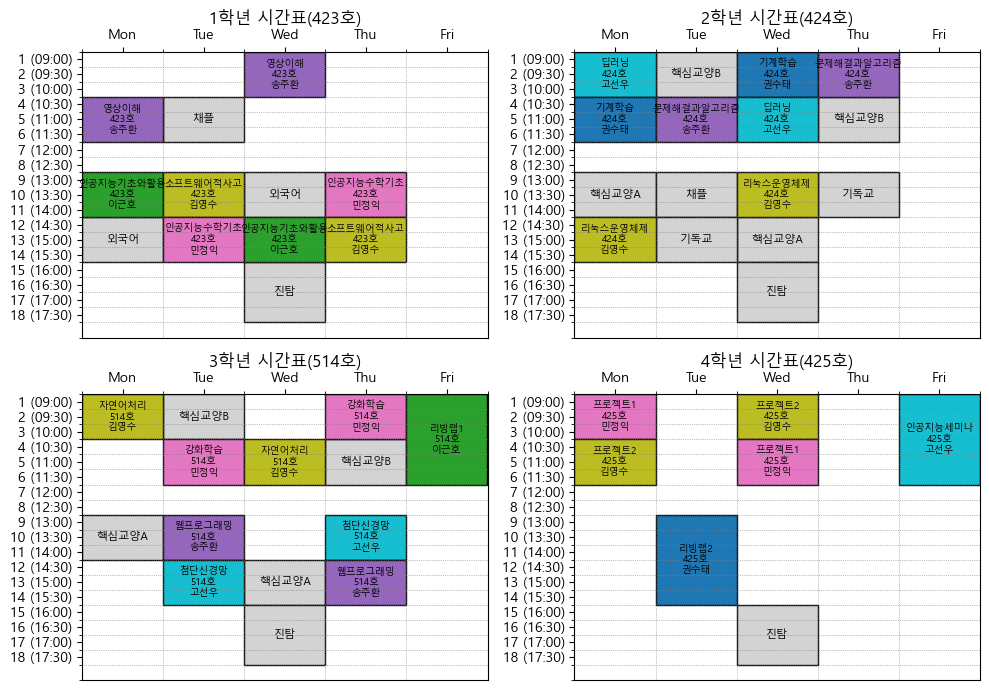

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
np.random.seed(0)
random.seed(0)

# --- 문제 데이터 ---
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
rooms = {1: "423호", 2: "424호", 3: "514호", 4: "425호"}
courses = [
    (1, "영상이해", "송주환", "1.5"),
    (1, "인공지능기초와활용", "이근호", "1.5"),
    (1, "인공지능수학기초", "민정익", "1.5"),
    (1, "소프트웨어적사고", "김영수", "1.5"),
    (3, "리빙랩1", "이근호", "3h"),
    (2, "문제해결과알고리즘", "송주환", "1.5"),
    (2, "리눅스운영체제", "김영수", "1.5"),
    (2, "기계학습", "권수태", "1.5"),
    (2, "딥러닝", "고선우", "1.5"),
    (3, "웹프로그래밍", "송주환", "1.5"),
    (3, "자연어처리", "김영수", "1.5"),
    (3, "강화학습", "민정익", "1.5"),
    (3, "첨단신경망", "고선우", "1.5"),
    (4, "인공지능세미나", "고선우", "3h"),
    (4, "리빙랩2", "권수태", "3h"),
    (4, "프로젝트1", "민정익", "1.5"),
    (4, "프로젝트2", "김영수", "1.5"),
]

# 학년별 고정 수업 (진탐 포함)
fixed_slots = {
    1: [(0, 11, 3, "외국어"), (2, 8, 3, "외국어"), (1, 3, 3, "채플"), (2, 14, 4, "진탐")],
    2: [(0, 8, 3, "핵심교양A"), (2, 11, 3, "핵심교양A"),
        (1, 0, 3, "핵심교양B"), (3, 3, 3, "핵심교양B"),
        (1, 8, 3, "채플"), (1, 11, 3, "기독교"), (3, 8, 3, "기독교"),
        (2, 14, 4, "진탐")],
    3: [(0, 8, 3, "핵심교양A"), (2, 11, 3, "핵심교양A"),
        (1, 0, 3, "핵심교양B"), (3, 3, 3, "핵심교양B"),
        (2, 14, 4, "진탐")],
    4: [(2, 14, 4, "진탐")]
}

# forbidden 시간대
forbidden = {
    1: {(0, p) for p in [12,13,14]} | {(2, p) for p in [9,10,11,15,16,17,18]} | {(1, p) for p in [4,5,6]},
    2: {(0, p) for p in [9,10,11]} | {(2, p) for p in [12,13,14,15,16,17,18]} |
       {(1, p) for p in [1,2,3]} | {(3, p) for p in [4,5,6]} |
       {(1, p) for p in [9,10,11,12,13,14]} | {(3, p) for p in [9,10,11]},
    3: {(0, p) for p in [9,10,11]} | {(2, p) for p in [12,13,14,15,16,17,18]} |
       {(1, p) for p in [1,2,3]} | {(3, p) for p in [4,5,6]},
    4: {(2, p) for p in [15,16,17,18]}
}

# 1.5h 짝꿍 슬롯 정의
slot_pairs_1_5 = [
    ((0,1),(2,4)), ((0,4),(2,1)), ((0,9),(2,12)), ((0,12),(2,9)),
    ((1,1),(3,4)), ((1,4),(3,1)), ((1,9),(3,12)), ((1,12),(3,9))
]

# 가능한 슬롯 생성 (3h: 월~목 우선, 그 다음 금 오전/오후)
possible_slots = []
for year, _, _, typ in courses:
    if typ == "1.5":
        choices = slot_pairs_1_5
    else:
        choices = []
        for d in range(4):
            for start in range(1, 10):
                if any((d, start+off) in forbidden[year] for off in range(6)):
                    continue
                choices.append(((d, start),))
        for start in (1, 9):
            if all((4, start+off) not in forbidden[year] for off in range(6)):
                choices.append(((4, start),))
    length = 3 if typ=="1.5" else 6
    filtered = [
        ch for ch in choices
        if all((d, p+off) not in forbidden[year] for d,p in ch for off in range(length))
    ]
    possible_slots.append(filtered)

# 크로모솜 디코드
def decode_gene(gene):
    assignments = []
    for idx, g in enumerate(gene):
        year, name, prof, typ = courses[idx]
        ch = possible_slots[idx][g]
        if typ == "1.5":
            for d, p in ch:
                for off in range(3):
                    assignments.append((year, name, prof, d, p+off))
        else:
            d, p = ch[0]
            for off in range(6):
                assignments.append((year, name, prof, d, p+off))
    return assignments

# 적합도 및 위반 내역 계산
def fitness_and_violations(gene):
    assign = decode_gene(gene)
    vio = {'year_conflict':0,'prof_conflict':0,'lunch':0,'forbidden':0,'soft_days':0}
    occ_y, occ_p, prof_days = {}, {}, {}
    for year,name,prof,d,p in assign:
        if occ_y.get((year,d,p)): vio['year_conflict']+=1
        occ_y.setdefault((year,d,p),[]).append(name)
        if (prof,d,p) in occ_p: vio['prof_conflict']+=1
        occ_p[(prof,d,p)] = name
        if p in (7,8): vio['lunch']+=1
        if (d,p) in forbidden[year]: vio['forbidden']+=1
        prof_days.setdefault(prof,set()).add(d)
    for ds in prof_days.values():
        if len(ds)<4: vio['soft_days'] += (4-len(ds))
    hard = vio['year_conflict']+vio['prof_conflict']+vio['lunch']+vio['forbidden']
    soft = vio['soft_days']
    return -(100*hard + soft), vio

# GA 파라미터 및 실행
NUM = len(courses)
POP, GENS, TOURN, CROSS, MUT, ELITE = 100, 200, 3, 0.8, 0.2, 2
population = [(*fitness_and_violations([random.randrange(len(ps)) for ps in possible_slots]), [random.randrange(len(ps)) for ps in possible_slots]) for _ in range(POP)]
best = max(population, key=lambda x: x[0])
for _ in range(GENS):
    new_pop = sorted(population, key=lambda x: x[0], reverse=True)[:ELITE]
    while len(new_pop) < POP:
        p1 = max(random.sample(population, TOURN), key=lambda x: x[0])[2]
        p2 = max(random.sample(population, TOURN), key=lambda x: x[0])[2]
        if random.random() < CROSS:
            pt = random.randint(1, NUM-1)
            c1, c2 = p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]
        else:
            c1, c2 = p1[:], p2[:]
        for child in (c1, c2):
            for i in range(NUM):
                if random.random() < MUT:
                    child[i] = random.randrange(len(possible_slots[i]))
            new_pop.append((*fitness_and_violations(child), child))
            if len(new_pop) >= POP:
                break
    population = new_pop
    curr = max(population, key=lambda x: x[0])
    if curr[0] > best[0]:
        best = curr

bf, bv, bg = best
print("=== 최종 결과 ===")
print("Best Fitness:", bf)
print("Violation breakdown:")
for k, v in bv.items():
    print(f"  {k}: {v}")

# 시간표 구축 (18교시)
schedule = {y: [["" for _ in days] for _ in range(18)] for y in range(1,5)}
schedule_prof = {y: [["" for _ in days] for _ in range(18)] for y in range(1,5)}
for year,name,prof,d,p in decode_gene(bg):
    schedule[year][p-1][d] = name
    schedule_prof[year][p-1][d] = prof

# 교수색 & y축 라벨 정의
profs = list({prof for *_ ,prof,_ in courses})
cmap = plt.cm.get_cmap('tab10', len(profs))
colors = {prof: cmap(i) for i, prof in enumerate(profs)}
yticks = list(range(18))
ylabels = [f"{i+1} ({9 + (i//2):02d}:{(i%2)*30:02d})" for i in yticks]

# 시각화 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for idx, ax in enumerate(axes, start=1):
    ax.set_title(f"{idx}학년 시간표({rooms[idx]})", pad=20)
    ax.xaxis.tick_top()
    ax.set_xticks(range(5)); ax.set_xticklabels(days)
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels)
    ax.set_ylim(17.5, -0.5); ax.set_xlim(-0.5, 4.5)
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 19, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle=":", linewidth=0.5)

    # 고정 수업 (회색)
    for day, st, span, nm in fixed_slots[idx]:
        rect = Rectangle((day-0.5, st-0.5), 1, span, facecolor='lightgrey', edgecolor='black')
        ax.add_patch(rect)
        ax.text(day, st + (span-1)/2, nm, ha="center", va="center", fontsize=8)

    # 가변 수업 (병합, 색상, 강의실 포함)
    for day in range(5):
        per = 0
        while per < 18:
            nm = schedule[idx][per][day]
            pf = schedule_prof[idx][per][day]
            if nm:
                run = 1
                while per+run < 18 and schedule[idx][per+run][day] == nm:
                    run += 1
                room = rooms[idx]
                color = colors[pf]
                rect = Rectangle((day-0.5, per-0.5), 1, run, facecolor=color, edgecolor='black')
                ax.add_patch(rect)
                ax.text(day, per + (run-1)/2, f"{nm}\n{room}\n{pf}", ha="center", va="center", fontsize=7)
                per += run
            else:
                per += 1

plt.tight_layout()
plt.show()


## 4번 설명